# Shape HG — fixation-baseline normalisation ablation

**Question.** Is the per-(trial × channel) **fixation z-score** the right normalisation, or is it mostly adding instability? What is it actually for — baseline / nuisance rejection, per-channel gain equalisation, or "just detrending"?

**Conditions — only the fixation-window normalisation changes:**

| | formula | rationale |
|---|---|---|
| `zscore` | `(env − μ_fix) / σ_fix` | current baseline |
| **A · `subtract`** | `env − μ_fix` | additive baseline correction only; per-feature scaling left to the downstream `StandardScaler` |
| **B · `relchange`** | `(env − μ_fix) / μ_fix` | fractional change from baseline; divides by the **well-estimated mean**, not the poorly-estimated SD; also equalises per-channel gain |
| `none` | `env` | reference point — is any fixation normalisation needed? |

Everything else identical: 70–150 Hz, 488 ms MA, 10 Hz envelope low-pass, downsample, channels, real-trial draws, SLOO folds, Linear SVM (C=0.1).


In [1]:
import sys, warnings, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

ROOT = Path.cwd()
REPO = ROOT if (ROOT / "scripts" / "seeg_io.py").exists() else ROOT.parent
sys.path.insert(0, str(REPO / "scripts"))

from seeg_io import SEEGDataset
from decoding import _svm, HIGH_GAMMA_HZ
from spectral_exp import (viable_region_pool, build_hg_tensors, run_condition, viz_smooth,
                          region_diff, summary_row,
                          SPATIAL_CUE_WINDOW, SPATIAL_DELAY_WINDOW, SHAPE_CUE_WINDOW, SHAPE_DELAY_WINDOW)

TASK          = "shape"
DATA_FILE     = "Prefrontal_MNM_Session.mat"
N_CLASSES     = 8
CHANCE        = 1.0 / N_CLASSES
CUE_WINDOW    = SHAPE_CUE_WINDOW
DELAY_WINDOW  = SHAPE_DELAY_WINDOW

REF, N_TRIALS_PER_CLASS, DOWNSAMPLE = "Laplacian", 3, 20
C_SVM, N_CV_REPEATS, N_RESAMPLES, N_CHANNELS, SEED = 0.1, 5, 10, 80, 0

ds = SEEGDataset(REPO / "data" / DATA_FILE)
FS = ds.fs
REGIONS = ["Dorsal", "Ventral"]
POOLS = {r: viable_region_pool(ds, r, required_classes=N_CLASSES) for r in REGIONS}

print("=" * 60); print("CONFIGURATION"); print("=" * 60)
for k, v in [("Task", TASK), ("Reference", REF), ("Band (Hz)", HIGH_GAMMA_HZ),
             ("Envelope low-pass (Hz)", 10.0), ("Moving average", "488 ms baseline"),
             ("Fixation window", "0.25-0.75 s"), ("Trials/class", N_TRIALS_PER_CLASS),
             ("Chance", f"{CHANCE:.4f}"), ("Downsample", DOWNSAMPLE),
             ("Effective step (ms)", f"{DOWNSAMPLE/FS*1000:.1f}"),
             ("Classifier", f"Linear SVM C={C_SVM}"), ("CV", "SLOO x5 = 15 folds"),
             ("Channel resamples", N_RESAMPLES), ("Channels/subsample", N_CHANNELS),
             ("Seeds", f"all from SEED={SEED}"),
             ("cue / delay window (s)", f"{CUE_WINDOW} / {DELAY_WINDOW}")]:
    print(f"  {k:24s}: {v}")
for r in REGIONS:
    print(f"  {'viable channels ' + r:24s}: {len(POOLS[r])}")
print("\nWindows are APPROXIMATE. Pseudo-population rows are class-matched population "
      "vectors, NOT simultaneously recorded trials.")


CONFIGURATION
  Task                    : shape
  Reference               : Laplacian
  Band (Hz)               : (70.0, 150.0)
  Envelope low-pass (Hz)  : 10.0
  Moving average          : 488 ms baseline
  Fixation window         : 0.25-0.75 s
  Trials/class            : 3
  Chance                  : 0.1250
  Downsample              : 20
  Effective step (ms)     : 39.1
  Classifier              : Linear SVM C=0.1
  CV                      : SLOO x5 = 15 folds
  Channel resamples       : 10
  Channels/subsample      : 80
  Seeds                   : all from SEED=0
  cue / delay window (s)  : (1.0, 2.0) / (2.5, 7.5)
  viable channels Dorsal  : 115
  viable channels Ventral : 141

Windows are APPROXIMATE. Pseudo-population rows are class-matched population vectors, NOT simultaneously recorded trials.


In [2]:
# ---------------------------------------------------------------- QC helpers
def qc(pop, label):
    X, y = pop.X, pop.y
    bad = int((~np.isfinite(X)).sum())
    pc = np.bincount(y)[np.bincount(y) > 0]
    ok = (bad == 0 and np.all(pc == N_TRIALS_PER_CLASS)
          and int(np.unique(y).size) == N_CLASSES and abs(pop.chance - CHANCE) < 1e-9)
    print(f"  {label:12s} X{X.shape} n_train/fold={X.shape[0]-N_CLASSES} "
          f"non-finite={bad} classes={np.unique(y).size} {'OK' if ok else 'FAIL'}")
    assert ok, f"QC failed: {label}"

def check_paired(a, b, label):
    ok = (np.array_equal(a.y, b.y) and np.array_equal(a.time_s, b.time_s)
          and a.channel_indices == b.channel_indices)
    print(f"  paired [{label}]: y/time/channels identical = {ok}")
    assert ok


In [3]:
# ------------------------------------------------------ computational cost
MODES = ["zscore", "subtract", "relchange", "none"]
_p = build_hg_tensors(ds, POOLS["Dorsal"], n_resamples=1, n_channels=N_CHANNELS,
                      ref=REF, downsample=DOWNSAMPLE, seed=SEED)[0]
N_BINS, N_FOLDS = _p.X.shape[2], N_TRIALS_PER_CLASS * N_CV_REPEATS
approx = len(REGIONS) * len(MODES) * N_RESAMPLES * (N_BINS * N_FOLDS + 2 * N_FOLDS)
print(f"regions={len(REGIONS)} modes={len(MODES)} resamples={N_RESAMPLES} "
      f"time-bins={N_BINS} SLOO-folds={N_FOLDS}")
print(f"approx model fits (full run): {approx:,}")


regions=2 modes=4 resamples=10 time-bins=244 SLOO-folds=15
approx model fits (full run): 295,200


## Smoke test (tiny config — NOT final)

In [4]:
for mode in MODES:
    T = build_hg_tensors(ds, POOLS["Dorsal"], n_resamples=2, n_channels=50, ref=REF,
                         downsample=40, baseline_mode=mode, seed=SEED)
    d = run_condition(T, [0], lambda: _svm(C_SVM), n_cv_repeats=2,
                      cue_window=CUE_WINDOW, delay_window=DELAY_WINDOW)
    X = T[0].X.ravel()
    print(f"  {mode:10s} skew={skew(X):+.2f} |x|>10 frac={(np.abs(X)>10).mean():.2e} "
          f"delay={d['delay_mean']:.3f}")
print("smoke OK")


  zscore     skew=+11.49 |x|>10 frac=6.34e-02 delay=0.260


  subtract   skew=+7.61 |x|>10 frac=1.11e-02 delay=0.156


  relchange  skew=+8.98 |x|>10 frac=4.88e-05 delay=0.198


  none       skew=+4.19 |x|>10 frac=3.79e-02 delay=0.083
smoke OK


## Full run

In [5]:
RES, TENS = {}, {}
t0 = time.time()
for reg in REGIONS:
    RES[reg], TENS[reg] = {}, {}
    for mode in MODES:
        T = build_hg_tensors(ds, POOLS[reg], n_resamples=N_RESAMPLES, n_channels=N_CHANNELS,
                             ref=REF, downsample=DOWNSAMPLE, baseline_mode=mode, seed=SEED)
        qc(T[0], f"{reg}/{mode}")
        TENS[reg][mode] = T
        RES[reg][mode] = run_condition(T, [0], lambda: _svm(C_SVM), n_cv_repeats=N_CV_REPEATS,
                                       cue_window=CUE_WINDOW, delay_window=DELAY_WINDOW)
    for mode in MODES[1:]:
        check_paired(TENS[reg]["zscore"][0], TENS[reg][mode][0], f"{reg}/{mode}")
print(f"full run done in {time.time() - t0:.0f}s")


  Dorsal/zscore X(24, 78, 244) n_train/fold=16 non-finite=0 classes=8 OK


  Dorsal/subtract X(24, 78, 244) n_train/fold=16 non-finite=0 classes=8 OK


  Dorsal/relchange X(24, 78, 244) n_train/fold=16 non-finite=0 classes=8 OK


  Dorsal/none  X(24, 78, 244) n_train/fold=16 non-finite=0 classes=8 OK


  paired [Dorsal/subtract]: y/time/channels identical = True
  paired [Dorsal/relchange]: y/time/channels identical = True
  paired [Dorsal/none]: y/time/channels identical = True


  Ventral/zscore X(24, 80, 244) n_train/fold=16 non-finite=0 classes=8 OK


  Ventral/subtract X(24, 80, 244) n_train/fold=16 non-finite=0 classes=8 OK


  Ventral/relchange X(24, 80, 244) n_train/fold=16 non-finite=0 classes=8 OK


  Ventral/none X(24, 80, 244) n_train/fold=16 non-finite=0 classes=8 OK


  paired [Ventral/subtract]: y/time/channels identical = True
  paired [Ventral/relchange]: y/time/channels identical = True
  paired [Ventral/none]: y/time/channels identical = True
full run done in 1089s


## Feature-distribution diagnostics (what each normalisation produces)

region   mode          skew    |x|max   |x|>10             p1/p50/p99 finite
Dorsal   zscore       12.50     406.1     7.4% [-14.513, -0.396, 44.24]  True
Dorsal   subtract      3.50      49.9     1.4% [-6.606, -0.052, 10.133]  True
Dorsal   relchange     9.76      15.2     0.1% [-0.603, -0.018, 2.734]  True
Dorsal   none          2.58      57.3     6.0%  [1.531, 3.17, 17.582]  True
Ventral  zscore       45.79    1946.3     7.1% [-14.89, -0.21, 34.522]  True
Ventral  subtract     47.98     426.0     1.1% [-4.923, -0.041, 8.013]  True
Ventral  relchange    53.02      92.8     0.1% [-0.574, -0.011, 1.74]  True
Ventral  none         44.79     430.6     3.6% [1.427, 3.962, 16.537]  True


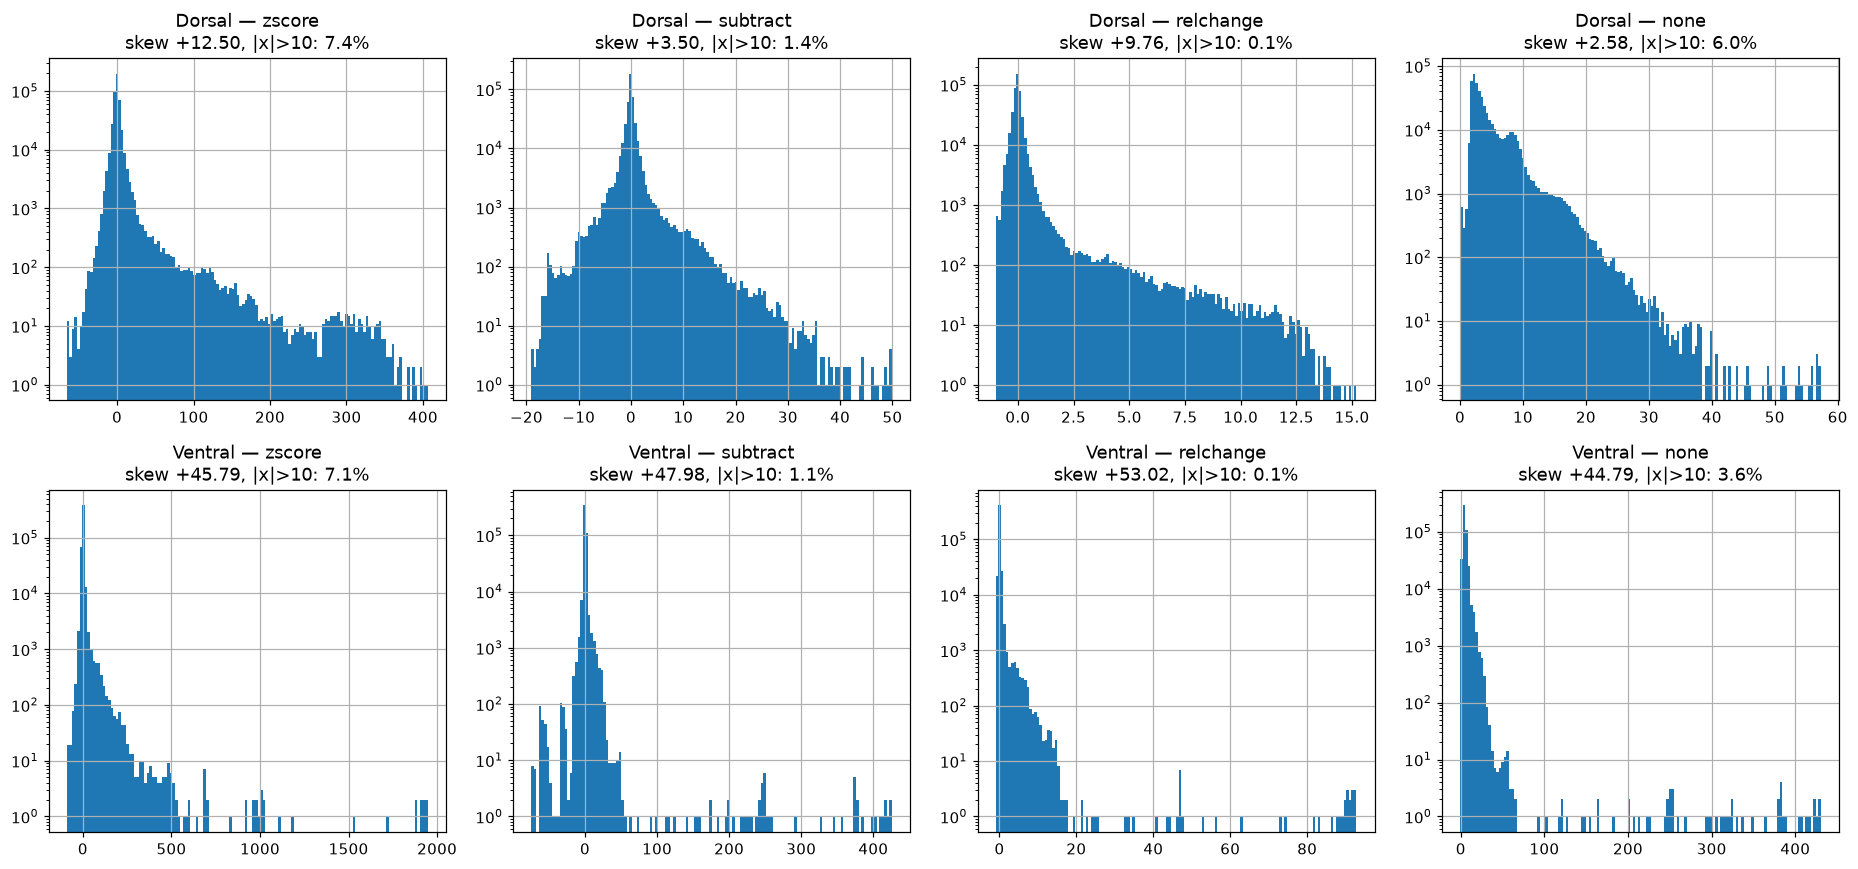

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
diag = []
for i, reg in enumerate(REGIONS):
    for j, mode in enumerate(MODES):
        X = TENS[reg][mode][0].X.ravel()
        Xf = X[np.isfinite(X)]
        diag.append((reg, mode, float(skew(Xf)), float(np.abs(Xf).max()),
                     float((np.abs(Xf) > 10).mean()), np.nanpercentile(Xf, [1, 50, 99]).round(3).tolist(),
                     bool(np.isfinite(X).all())))
        ax = axes[i][j]
        ax.hist(Xf, bins=140, color="tab:blue"); ax.set_yscale("log")
        ax.set_title(f"{reg} — {mode}\nskew {skew(Xf):+.2f}, |x|>10: {(np.abs(Xf)>10).mean():.1%}")
plt.tight_layout()

print(f"{'region':8s} {'mode':10s} {'skew':>7s} {'|x|max':>9s} {'|x|>10':>8s} {'p1/p50/p99':>22s} finite")
for reg, mode, sk, mx, of, pct, fin in diag:
    print(f"{reg:8s} {mode:10s} {sk:7.2f} {mx:9.1f} {of:8.1%} {str(pct):>22s}  {fin}")


## Time-resolved decoding by normalisation, per region

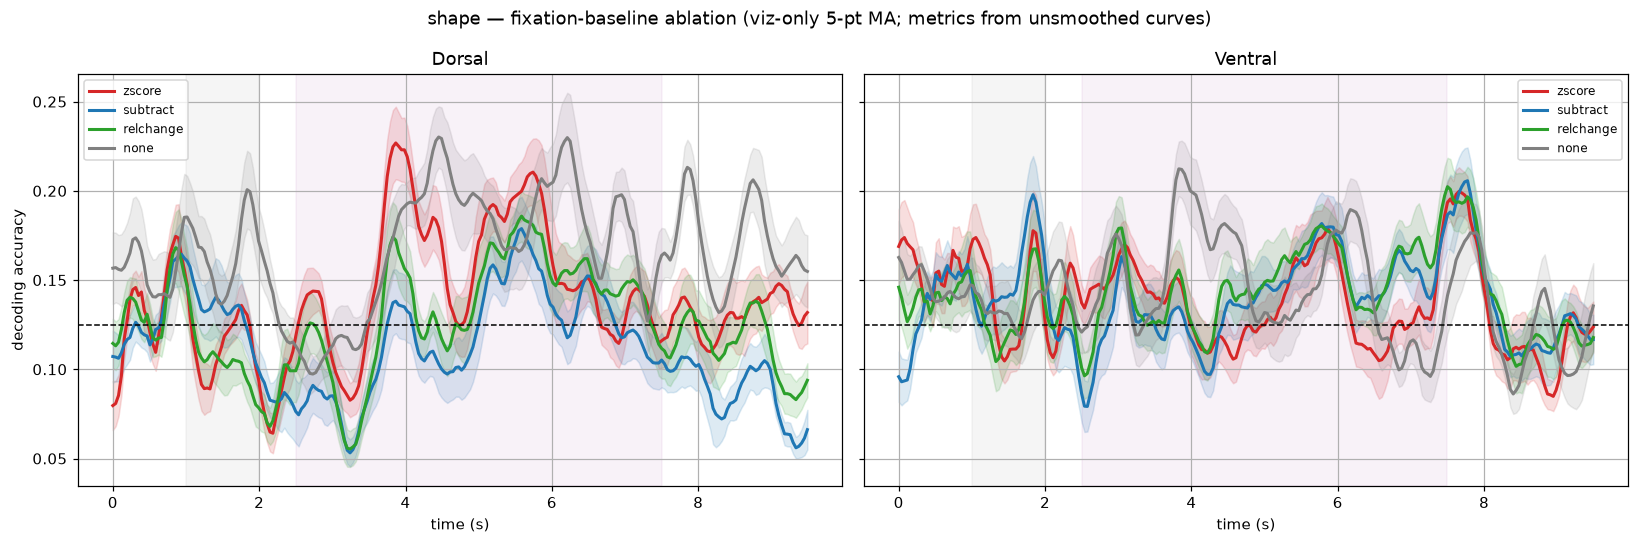

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
col = {"zscore": "tab:red", "subtract": "tab:blue", "relchange": "tab:green", "none": "grey"}
for ax, reg in zip(axes, REGIONS):
    for mode in MODES:
        d = RES[reg][mode]
        m, se = viz_smooth(d["curves"], 5)
        ax.plot(d["time_s"], m, color=col[mode], lw=2, label=mode)
        ax.fill_between(d["time_s"], m - se, m + se, color=col[mode], alpha=0.15)
    ax.axhline(CHANCE, color="k", ls="--", lw=1)
    ax.axvspan(*CUE_WINDOW, color="grey", alpha=0.08)
    ax.axvspan(*DELAY_WINDOW, color="purple", alpha=0.05)
    ax.set_title(reg); ax.set_xlabel("time (s)"); ax.legend(fontsize=8)
axes[0].set_ylabel("decoding accuracy")
fig.suptitle(f"{TASK} — fixation-baseline ablation (viz-only 5-pt MA; metrics from unsmoothed curves)")
plt.tight_layout()


## Summary table

`Task | Region | Normalisation | Peak Acc | Peak Time | Cue Mean | Delay Mean | Delay Peak | Delay SD | skew | |x|>10`

In [8]:
skew_lookup = {(reg, mode): (sk, of) for reg, mode, sk, mx, of, pct, fin in diag}
print(f"{'Task':8s} {'Region':8s} {'Norm':10s} {'PeakAcc':>8s} {'PeakT':>6s} "
      f"{'CueMean':>8s} {'DelayMn':>8s} {'DelayPk':>8s} {'DelaySD':>8s} {'skew':>7s} {'|x|>10':>7s}")
for reg in REGIONS:
    for mode in MODES:
        d = RES[reg][mode]; sk, of = skew_lookup[(reg, mode)]
        print(f"{TASK:8s} {reg:8s} {mode:10s} {d['peak_mean']:8.3f} {d['peak_t_mean']:6.2f} "
              f"{d['cue_mean']:8.3f} {d['delay_mean']:8.3f} {d['delay_peak_mean']:8.3f} "
              f"{d['delay_std']:8.3f} {sk:7.2f} {of:7.1%}")

print("\ndescriptive Dorsal - Ventral (delay window, NOT significance):")
for mode in MODES:
    rd = region_diff(RES["Dorsal"][mode], RES["Ventral"][mode])
    print(f"  {mode:10s}  cue D-V={rd['cue_diff']:+.3f}  delay D-V={rd['delay_diff']:+.3f}")


Task     Region   Norm        PeakAcc  PeakT  CueMean  DelayMn  DelayPk  DelaySD    skew  |x|>10
shape    Dorsal   zscore        0.328   3.63    0.122    0.172    0.312    0.050   12.50    7.4%
shape    Dorsal   subtract      0.271   2.82    0.139    0.141    0.253    0.053    3.50    1.4%
shape    Dorsal   relchange     0.298   3.65    0.084    0.178    0.268    0.066    9.76    0.1%
shape    Dorsal   none          0.328   3.80    0.168    0.175    0.309    0.096    2.58    6.0%
shape    Ventral  zscore        0.329   2.66    0.135    0.168    0.275    0.045   45.79    7.1%
shape    Ventral  subtract      0.303   3.13    0.172    0.160    0.266    0.045   47.98    1.1%
shape    Ventral  relchange     0.318   3.29    0.143    0.172    0.297    0.044   53.02    0.1%
shape    Ventral  none          0.288   4.70    0.133    0.174    0.275    0.055   44.79    3.6%

descriptive Dorsal - Ventral (delay window, NOT significance):
  zscore      cue D-V=-0.013  delay D-V=+0.003
  subtract    cu